# NB3 — Regression Analysis
**Zombie Firms Replication** — *Geographical Analysis of the Italian Industrial North*

**Input:** `zombie_panel_classified.parquet` (NB1/NB2 output)  
**Output:** `nb3_regression_results.csv`, `nb3_regression_tables.txt`

---
### Empirical strategy

The regression follows the framework of McGowan, Andrews & Millot (2018) and Caballero et al. (2008), estimating the effect of zombie firm congestion on the investment and employment growth of non-zombie (viable) firms in the same province and sector.

**The key identification assumption** is that, conditional on firm and year fixed effects, variation in the local zombie share within a province-sector cell is driven by credit misallocation and forbearance rather than by common demand shocks. The zombie congestion term captures the extent to which zombie firms crowd out resources — credit, labour, customers — that would otherwise be available to viable firms.

---
### Models estimated

**Model 1 — Investment rate (primary)**
$$\text{inv}_{it} = \alpha_i + \lambda_t + \beta_1 \cdot \text{ZombieShare}_{pst} + \beta_2 \cdot \text{ZombieShare}_{pst} \times \text{HCI}_{it} + \varepsilon_{it}$$

**Model 2 — Employment growth (primary)**
$$\Delta \log \text{emp}_{it} = \alpha_i + \lambda_t + \beta_1 \cdot \text{ZombieShare}_{pst} + \varepsilon_{it}$$

**Model 3 — Investment rate with sector×year FE**  
Replaces year FE with sector×year FE to absorb industry-wide demand and technology shocks.

**Model 4 — Own zombie status**  
Estimates the within-firm effect of transitioning into and out of zombie status on investment.

Where:
- $\alpha_i$ = firm fixed effects (absorb all time-invariant firm characteristics)
- $\lambda_t$ = year fixed effects (absorb aggregate macro shocks)
- $\text{ZombieShare}_{pst}$ = share of zombie firms in province $p$, NACE 2-digit sector $s$, year $t$ (McGowan definition)
- $\text{HCI}_{it}$ = high-credit-intensity indicator (above-median financial expenses / total assets), following McGowan et al.
- Sample restricted to **non-zombie viable firms** for Models 1–3 (the spillover channel); Model 4 uses all firms

Standard errors are clustered at the **province × sector** level throughout.


In [41]:
from pathlib import Path

# ── SETTINGS ──────────────────────────────────────────────────────────────────

BASE_DIR    = Path("/Users/leoss/Desktop/Thesis Replication/output")
INPUT_FILE  = BASE_DIR / "zombie_panel_classified.parquet"
OUTPUT_DIR  = BASE_DIR
FIG_DIR     = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

# Regression sample years (2018+ so McGowan has full 3-year history)
REG_YEARS = list(range(2018, 2025))

# Zombie definition used for congestion term
PRIMARY_ZOMBIE = 'zombie_mcgowan'

# Outlier winsorisation (percentile, applied to dep vars and key regressors)
WINSOR_P = 0.01   # 1% each tail

# Minimum observations per province-sector cell to include in regression
MIN_OBS_CELL = 5

# ── END SETTINGS ──────────────────────────────────────────────────────────────
print(f"Input  : {INPUT_FILE}")
print(f"Figures: {FIG_DIR}")
print(f"Regression years: {REG_YEARS[0]}–{REG_YEARS[-1]}")


Input  : /Users/leoss/Desktop/Thesis Replication/output/zombie_panel_classified.parquet
Figures: /Users/leoss/Desktop/Thesis Replication/output/figures
Regression years: 2018–2024


In [42]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)

# Try to import linearmodels for panel FE with clustered SEs
try:
    from linearmodels.panel import PanelOLS, BetweenOLS
    from linearmodels import IV2SLS
    HAS_LINEARMODELS = True
    print("linearmodels available — using PanelOLS with clustered SEs")
except ImportError:
    HAS_LINEARMODELS = False
    print("linearmodels not found — install with: pip install linearmodels")
    print("Falling back to statsmodels with manual within-transform")

try:
    import statsmodels.formula.api as smf
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels not found")


linearmodels available — using PanelOLS with clustered SEs


## 1. Load and prepare regression sample

In [43]:
df = pd.read_parquet(INPUT_FILE)
print(f"Loaded: {len(df):,} rows | {df['bvd_id'].nunique():,} firms")

# Restrict to regression years
df = df[df['year'].isin(REG_YEARS)].copy()
print(f"After year filter ({REG_YEARS[0]}–{REG_YEARS[-1]}): {len(df):,} rows | {df['bvd_id'].nunique():,} firms")


Loaded: 672,534 rows | 74,726 firms
After year filter (2018–2024): 523,082 rows | 74,726 firms


### 1.1 Construct dependent variables

**Investment rate** is already computed in NB0 as Δ(Tangible FA) / lagged Total assets. It is winsorised at the 1st and 99th percentiles to limit the influence of extreme outliers from asset revaluations and disposals.

**Employment growth** is log-differenced employees: $\Delta \log \text{emp}_{it} = \log \text{emp}_{it} - \log \text{emp}_{i,t-1}$. Requires at least two consecutive years of non-missing employee data.


In [44]:
def winsorise(s, p=WINSOR_P):
    lo, hi = s.quantile(p), s.quantile(1-p)
    return s.clip(lo, hi)

df = df.sort_values(['bvd_id', 'year'])

# Investment rate — already in panel, winsorise
df['inv_rate_w'] = winsorise(df['investment_rate'])

# Employment growth
df['log_emp'] = np.log(df['employees'].clip(lower=1))
df['emp_growth'] = df.groupby('bvd_id')['log_emp'].diff()
df['emp_growth_w'] = winsorise(df['emp_growth'])

# Log total assets (size control)
df['log_ta'] = np.log(df['total_assets'].clip(lower=1))

# Lagged ICR — winsorise level first, then lag (check 5)
# Winsorising after taking the lag propagates outlier values into the regressor.
df['icr_w']     = winsorise(df['icr'])          # winsorise level
df['icr_lag_w'] = df.groupby('bvd_id')['icr_w'].shift(1)  # then lag

# High credit intensity: above-median financial expenses / total assets
df['fin_intensity'] = df['financial_expenses'] / df['total_assets'].replace(0, np.nan)
fi_median = df['fin_intensity'].median()
df['high_credit'] = (df['fin_intensity'] > fi_median).astype(float)
df.loc[df['fin_intensity'].isna(), 'high_credit'] = np.nan

print("Dependent variables constructed:")
for v in ['inv_rate_w', 'emp_growth_w']:
    sub = df[v].dropna()
    print(f"  {v}: n={len(sub):,}  mean={sub.mean():.4f}  sd={sub.std():.4f}  "
          f"p10={sub.quantile(.1):.4f}  p90={sub.quantile(.9):.4f}")


Dependent variables constructed:
  inv_rate_w: n=462,035  mean=0.0216  sd=0.0954  p10=-0.0350  p90=0.0941
  emp_growth_w: n=302,248  mean=0.0188  sd=0.1445  p10=-0.1301  p90=0.1775


### 1.2 Construct zombie congestion term

The congestion term $\text{ZombieShare}_{pst}$ is the share of zombie firms in the same province and NACE 2-digit sector in year $t$. This is computed **excluding the firm itself** (leave-one-out) to avoid mechanical correlation between a firm's own zombie status and the congestion measure.

A firm with $n$ observations in a cell contributes $1/n$ to its own zombie share if it is a zombie. The leave-one-out correction removes this: $\text{ZombieShare}^{-i}_{pst} = \frac{N_{pst} \cdot \bar{Z}_{pst} - Z_{it}}{N_{pst} - 1}$


In [45]:
# Province × sector × year cell zombie share
cell_stats = (
    df[df[PRIMARY_ZOMBIE].notna()]
    .groupby(['province', 'nace_2digit', 'year'])
    .agg(
        cell_n_zombies = (PRIMARY_ZOMBIE, 'sum'),
        cell_n_firms   = (PRIMARY_ZOMBIE, 'count'),
    )
    .reset_index()
)
cell_stats['cell_zombie_share'] = cell_stats['cell_n_zombies'] / cell_stats['cell_n_firms']

df = df.merge(cell_stats, on=['province', 'nace_2digit', 'year'], how='left')

# Leave-one-out correction
mask = (df[PRIMARY_ZOMBIE].notna()) & (df['cell_n_firms'] > 1)
df['zombie_share_loo'] = np.where(
    mask,
    (df['cell_n_zombies'] - df[PRIMARY_ZOMBIE]) / (df['cell_n_firms'] - 1),
    df['cell_zombie_share']
)

# Drop cells below minimum size
small_cells = df['cell_n_firms'] < MIN_OBS_CELL
df.loc[small_cells, 'zombie_share_loo'] = np.nan

print(f"Congestion term (zombie_share_loo) constructed:")
print(f"  Non-missing: {df['zombie_share_loo'].notna().sum():,}")
print(f"  Mean: {df['zombie_share_loo'].mean():.4f}")
print(f"  Std : {df['zombie_share_loo'].std():.4f}")
print(f"  Province-sector cells with >= {MIN_OBS_CELL} firms: "
      f"{cell_stats[cell_stats['cell_n_firms']>=MIN_OBS_CELL].shape[0]:,}")


Congestion term (zombie_share_loo) constructed:
  Non-missing: 512,841
  Mean: 0.0385
  Std : 0.0385
  Province-sector cells with >= 5 firms: 10,626


In [46]:
# ── Capital-weighted congestion term (check 4 / McGowan et al. 2018) ────────────
# McGowan (2018) uses share of industry tangible fixed assets held by zombies,
# not firm-count share. Compute as robustness alternative to zombie_share_loo.

cap_stats = (
    df[df[PRIMARY_ZOMBIE].notna() & df['tangible_fa'].notna()]
    .groupby(['province', 'nace_2digit', 'year'])
    .apply(lambda g: pd.Series({
        'cap_zombie': (g[PRIMARY_ZOMBIE] * g['tangible_fa'].fillna(0)).sum(),
        'cap_total'  : g['tangible_fa'].fillna(0).sum(),
    }))
    .reset_index()
)
cap_stats['cap_zombie_share'] = np.where(
    cap_stats['cap_total'] > 0,
    cap_stats['cap_zombie'] / cap_stats['cap_total'],
    np.nan
)

# Merge ALL columns needed for LOO computation
df = df.merge(
    cap_stats[['province','nace_2digit','year','cap_zombie','cap_total','cap_zombie_share']],
    on=['province','nace_2digit','year'], how='left'
)

# Leave-one-out: subtract own capital contribution from numerator and denominator
own_cap   = df['tangible_fa'].fillna(0) * df[PRIMARY_ZOMBIE].fillna(0)
denom_loo = df['cap_total']   - df['tangible_fa'].fillna(0)
numer_loo = df['cap_zombie']  - own_cap

df['cap_zombie_share_loo'] = np.where(
    df[PRIMARY_ZOMBIE].notna() & df['tangible_fa'].notna(),
    np.where(denom_loo > 0, numer_loo / denom_loo, np.nan),
    df['cap_zombie_share']
)

# Drop merge helpers — keep only the derived share columns
df.drop(columns=['cap_zombie', 'cap_total'], inplace=True)

print('Capital-weighted congestion term (tangible FA share):')
print(f'  Non-missing: {df["cap_zombie_share_loo"].notna().sum():,}')
print(f'  Mean       : {df["cap_zombie_share_loo"].mean():.4f}')
print(f'  Std        : {df["cap_zombie_share_loo"].std():.4f}')
corr = df[['zombie_share_loo','cap_zombie_share_loo']].corr().iloc[0,1]
print(f'  Corr with count-share LOO: {corr:.3f}')


Capital-weighted congestion term (tangible FA share):
  Non-missing: 521,165
  Mean       : 0.0584
  Std        : 0.1088
  Corr with count-share LOO: 0.462


### 1.3 Regression samples

**Spillover sample (Models 1–3):** non-zombie viable firms only, with non-missing investment rate or employment growth, and non-missing congestion term. Firms that ever appear as zombies are retained in the non-zombie years (the fixed effects absorb permanent differences; what matters is the within-firm variation).

**Full sample (Model 4):** all firms with non-missing investment rate, used to estimate the own zombie status effect.


In [47]:
# Province-sector-year fixed effects identifier
df['ps_year_fe'] = (
    df['province'].astype(str) + '_' +
    df['nace_2digit'].astype(str) + '_' +
    df['year'].astype(str)
)
df['province_sector'] = df['province'].astype(str) + '_' + df['nace_2digit'].astype(str)

# Spillover sample: non-zombie firm-years
spill = df[
    (df[PRIMARY_ZOMBIE] == 0) &
    df['zombie_share_loo'].notna() &
    df['inv_rate_w'].notna()
].copy()

# Full sample
full = df[df['inv_rate_w'].notna() & df[PRIMARY_ZOMBIE].notna()].copy()

print(f"Spillover sample : {len(spill):,} firm-year obs | {spill['bvd_id'].nunique():,} firms")
print(f"Full sample      : {len(full):,} firm-year obs  | {full['bvd_id'].nunique():,} firms")
print()

# Summary stats for key variables in spillover sample
print("Spillover sample — key variable means:")
for v in ['inv_rate_w', 'emp_growth_w', 'zombie_share_loo', 'log_ta', 'icr_lag_w']:
    sub = spill[v].dropna()
    print(f"  {v:<22s}: mean={sub.mean():.4f}  sd={sub.std():.4f}  n={len(sub):,}")


Spillover sample : 434,292 firm-year obs | 72,530 firms
Full sample      : 462,035 firm-year obs  | 74,700 firms

Spillover sample — key variable means:
  inv_rate_w            : mean=0.0226  sd=0.0960  n=434,292
  emp_growth_w          : mean=0.0207  sd=0.1442  n=285,289
  zombie_share_loo      : mean=0.0380  sd=0.0378  n=434,292
  log_ta                : mean=8.1024  sd=1.5326  n=434,292
  icr_lag_w             : mean=247.9737  sd=1327.8317  n=351,220


## 2. Panel fixed effects regression

All models use the within (demeaning) estimator — firm fixed effects are absorbed by demeaning each variable at the firm level. Standard errors are clustered at the province × sector level to account for spatial correlation in shocks.

If `linearmodels` is available it handles the FE absorption and clustering directly. Otherwise a manual within-transform is applied and standard errors are clustered using a sandwich estimator via `statsmodels`.


In [48]:
def within_demean(data, dep_var, indep_vars, group='bvd_id'):
    """Manual within-transform (subtract firm means) for statsmodels fallback."""
    cols = [dep_var] + indep_vars + [group]
    sub = data[cols].dropna().copy().reset_index(drop=True)
    for col in [dep_var] + indep_vars:
        sub[col] = sub[col] - sub.groupby(group)[col].transform('mean')
    return sub


def cluster_ols(data, dep_var, indep_vars, cluster_var):
    """OLS with clustered SEs via statsmodels."""
    y = data[dep_var]
    X = sm.add_constant(data[indep_vars])
    res = sm.OLS(y, X).fit(
        cov_type='cluster',
        cov_kwds={'groups': data[cluster_var]}
    )
    return res


def run_panel_ols(data, dep_var, indep_vars, fe_var='bvd_id', cluster_var='province_sector',
                  time_var='year', label=''):
    """
    Panel OLS with firm FE + year FE, SEs clustered at province_sector level.
    Uses linearmodels PanelOLS when available, else manual within-transform + statsmodels.

    cluster_var must be a column in data but is NOT passed as a regressor —
    it is only used for SE clustering.
    """
    cols_needed = [dep_var] + indep_vars + [fe_var, time_var, cluster_var]
    sub = data[[c for c in cols_needed if c in data.columns]].dropna().copy()
    sub = sub.reset_index(drop=True)

    if len(sub) == 0:
        raise ValueError(f"Empty sample for model '{label}' after dropna.")

    if HAS_LINEARMODELS:
        # linearmodels requires a MultiIndex (entity, time)
        sub_idx = sub.set_index([fe_var, time_var])

        # cluster Series: same MultiIndex, values are the cluster identifier
        # Convert to integer codes so linearmodels accepts it
        cluster_codes = pd.Categorical(sub[cluster_var]).codes
        cluster_s = pd.Series(cluster_codes, index=sub_idx.index, name=cluster_var)

        mod = PanelOLS(
            dependent   = sub_idx[dep_var],
            exog        = sub_idx[indep_vars],
            entity_effects = True,
            time_effects   = True,
            drop_absorbed  = True,
        )
        res = mod.fit(
            cov_type       = 'clustered',
            cluster_entity = False,
            clusters       = cluster_s,
        )
        return res, sub, 'linearmodels'

    else:
        # statsmodels fallback: manual within-transform + year dummies
        year_dummies = pd.get_dummies(sub[time_var], prefix='yr', drop_first=True).astype(float)
        all_indep = indep_vars + list(year_dummies.columns)
        sub_aug = pd.concat([sub.reset_index(drop=True),
                             year_dummies.reset_index(drop=True)], axis=1)
        sub_w = within_demean(sub_aug, dep_var, all_indep, group=fe_var)
        # Re-attach cluster var (within_demean resets index so positions align)
        sub_w[cluster_var] = sub_aug.loc[sub_w.index, cluster_var].values
        res = cluster_ols(sub_w, dep_var, all_indep, cluster_var=cluster_var)
        return res, sub, 'statsmodels'


### 2.1 Model 1 — Investment rate ~ zombie congestion


In [49]:
indep_m1 = ['zombie_share_loo', 'log_ta', 'icr_lag_w']

res_m1, sub_m1, engine_m1 = run_panel_ols(
    spill, 'inv_rate_w', indep_m1,
    label='M1: Investment ~ zombie congestion'
)
print(f"Model 1 — Investment rate (engine_m1: {engine_m1})")
print(f"N = {len(sub_m1):,} obs | firms = {sub_m1['bvd_id'].nunique() if 'bvd_id' in sub_m1.columns else 'n/a':,}")
print()
if engine_m1 == 'linearmodels':
    print(res_m1.summary.tables[1])
else:
    print(res_m1.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


Model 1 — Investment rate (engine_m1: linearmodels)
N = 351,220 obs | firms = 70,329

                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0032     0.0092    -0.3517     0.7250     -0.0212      0.0148
log_ta               0.0453     0.0015     30.108     0.0000      0.0423      0.0482
icr_lag_w         1.821e-06  2.107e-07     8.6434     0.0000   1.408e-06   2.234e-06


### 2.2 Model 2 — Employment growth ~ zombie congestion


In [50]:
spill_emp = spill[spill['emp_growth_w'].notna()].copy()
indep_m2 = ['zombie_share_loo', 'log_ta']

res_m2, sub_m2, engine_m2 = run_panel_ols(
    spill_emp, 'emp_growth_w', indep_m2,
    label='M2: Employment growth ~ zombie congestion'
)
print(f"Model 2 — Employment growth (engine_m2: {engine_m2})")
print(f"N = {len(sub_m2):,} obs")
print()
if engine_m2 == 'linearmodels':
    print(res_m2.summary.tables[1])
else:
    print(res_m2.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


Model 2 — Employment growth (engine_m2: linearmodels)
N = 285,289 obs

                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0041     0.0152    -0.2694     0.7876     -0.0339      0.0257
log_ta               0.0567     0.0022     26.156     0.0000      0.0525      0.0610


### 2.3 Model 3 — Investment rate with credit intensity interaction

Following McGowan et al. (2018), the congestion effect may be stronger for firms that are more dependent on external credit. We interact the zombie share with a high-credit-intensity indicator (firms above the median ratio of financial expenses to total assets). The prediction is $\beta_2 < 0$: credit-intensive viable firms suffer a larger investment drag from zombie congestion.


In [51]:
spill_hc = spill[spill['high_credit'].notna()].copy()
spill_hc['zombie_x_hc'] = spill_hc['zombie_share_loo'] * spill_hc['high_credit']
indep_m3 = ['zombie_share_loo', 'zombie_x_hc', 'high_credit', 'log_ta', 'icr_lag_w']

res_m3, sub_m3, engine_m3 = run_panel_ols(
    spill_hc, 'inv_rate_w', indep_m3,
    label='M3: Investment ~ zombie congestion x credit intensity'
)
print(f"Model 3 — Investment x credit intensity (engine_m3: {engine_m3})")
print(f"N = {len(sub_m3):,} obs")
print()
if engine_m3 == 'linearmodels':
    print(res_m3.summary.tables[1])
else:
    print(res_m3.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


Model 3 — Investment x credit intensity (engine_m3: linearmodels)
N = 351,220 obs

                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0088     0.0119    -0.7395     0.4596     -0.0322      0.0146
zombie_x_hc          0.0112     0.0131     0.8497     0.3955     -0.0146      0.0369
high_credit         -0.0082     0.0008    -10.026     0.0000     -0.0098     -0.0066
log_ta               0.0453     0.0015     30.144     0.0000      0.0424      0.0483
icr_lag_w         1.769e-06  2.101e-07     8.4211     0.0000   1.357e-06   2.181e-06


### 2.4 Model 4 — Own zombie status and investment

Estimates the within-firm effect of zombie status on the firm's own investment rate. A firm that transitions into zombie status is expected to cut investment. Unlike Models 1–3 (which use the spillover sample), this model uses all firms including zombies.

Note: because zombie status is a consequence of low ICR rather than a cause, this coefficient should be interpreted descriptively rather than causally.


In [52]:
indep_m4 = [PRIMARY_ZOMBIE, 'log_ta', 'icr_lag_w']

res_m4, sub_m4, engine_m4 = run_panel_ols(
    full, 'inv_rate_w', indep_m4,
    label='M4: Investment ~ own zombie status'
)
print(f"Model 4 — Own zombie status (engine_m4: {engine_m4})")
print(f"N = {len(sub_m4):,} obs | firms = {sub_m4['bvd_id'].nunique() if 'bvd_id' in sub_m4.columns else 'n/a':,}")
print()
if engine_m4 == 'linearmodels':
    print(res_m4.summary.tables[1])
else:
    print(res_m4.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


Model 4 — Own zombie status (engine_m4: linearmodels)
N = 375,277 obs | firms = 72,649

                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
zombie_mcgowan    -0.0029     0.0011    -2.6933     0.0071     -0.0051     -0.0008
log_ta             0.0398     0.0013     30.229     0.0000      0.0372      0.0423
icr_lag_w        1.84e-06  2.067e-07     8.9024     0.0000   1.435e-06   2.245e-06


## 3. Summary results table

Collects coefficients and standard errors from all four models into a single display table. Significance stars: *** p<0.01, ** p<0.05, * p<0.10.


In [53]:
def extract_coefs(res, engine, vars_of_interest):
    """Extract coefficient, SE, and p-value for variables of interest."""
    out = {}
    if engine == 'linearmodels':
        params = res.params
        pvals  = res.pvalues
        ses    = res.std_errors
    else:
        params = res.params
        pvals  = res.pvalues
        ses    = res.bse

    for v in vars_of_interest:
        key = v if v in params.index else ('const' if v == 'const' else None)
        if key:
            coef, se, pv = params[key], ses[key], pvals[key]
            stars = '***' if pv < 0.01 else ('**' if pv < 0.05 else ('*' if pv < 0.10 else ''))
            out[v] = f"{coef:.4f}{stars}\n({se:.4f})"
        else:
            out[v] = '—'
    return out


key_vars = ['zombie_share_loo', 'zombie_x_hc', 'high_credit', PRIMARY_ZOMBIE, 'log_ta', 'icr_lag_w']
var_labels = {
    'zombie_share_loo' : 'Zombie share (province-sector)',
    'zombie_x_hc'      : '  × High credit intensity',
    'high_credit'      : 'High credit intensity',
    PRIMARY_ZOMBIE     : 'Own zombie status',
    'log_ta'           : 'Log total assets',
    'icr_lag_w'        : 'ICR (lagged)',
}

models = [
    ('M1: Inv. rate',    res_m1, engine_m1, sub_m1),
    ('M2: Emp. growth',  res_m2, engine_m2, sub_m2),
    ('M3: Inv. × credit',res_m3, engine_m3, sub_m3),
    ('M4: Own zombie',   res_m4, engine_m4, sub_m4),
]

rows = []
for v in key_vars:
    row = {'Variable': var_labels.get(v, v)}
    for label, res, eng, sub in models:
        coefs = extract_coefs(res, eng, [v])
        row[label] = coefs.get(v, '—')
    rows.append(row)

# Add N row
n_row = {'Variable': 'N (firm-year obs)'}
for label, res, eng, sub in models:
    n_row[label] = f"{len(sub):,}"
rows.append(n_row)

# FE row
fe_row = {'Variable': 'Firm FE / Year FE'}
for label, _, _, _ in models:
    fe_row[label] = 'Yes / Yes'
rows.append(fe_row)

results_df = pd.DataFrame(rows).set_index('Variable')
print("\n" + "="*80)
print("REGRESSION RESULTS — Zombie firm spillover effects on viable firms")
print("="*80)
print(results_df.to_string())
print("="*80)
print("Notes: Clustered SEs (province × sector) in parentheses.")
print("       *** p<0.01  ** p<0.05  * p<0.10")
print("       Models 1–3: spillover sample (non-zombie firm-years only).")
print("       Model 4: full sample, own zombie status effect.")

# Save
results_df.to_csv(OUTPUT_DIR / 'nb3_regression_results.csv')
with open(OUTPUT_DIR / 'nb3_regression_tables.txt', 'w') as f:
    f.write("REGRESSION RESULTS\n")
    f.write("="*80 + "\n")
    f.write(results_df.to_string())
    f.write("\n\nNotes: Clustered SEs (province × sector) in parentheses.\n")
    f.write("*** p<0.01  ** p<0.05  * p<0.10\n")
print("\nSaved: nb3_regression_results.csv, nb3_regression_tables.txt")



REGRESSION RESULTS — Zombie firm spillover effects on viable firms
                                      M1: Inv. rate      M2: Emp. growth     M3: Inv. × credit        M4: Own zombie
Variable                                                                                                            
Zombie share (province-sector)    -0.0032\n(0.0092)    -0.0041\n(0.0152)     -0.0088\n(0.0119)                     —
  × High credit intensity                         —                    —      0.0112\n(0.0131)                     —
High credit intensity                             —                    —  -0.0082***\n(0.0008)                     —
Own zombie status                                 —                    —                     —  -0.0029***\n(0.0011)
Log total assets                0.0453***\n(0.0015)  0.0567***\n(0.0022)   0.0453***\n(0.0015)   0.0398***\n(0.0013)
ICR (lagged)                    0.0000***\n(0.0000)                    —   0.0000***\n(0.0000)   0.0000***\n(0.00

## 4. Coefficient plot — zombie congestion effect

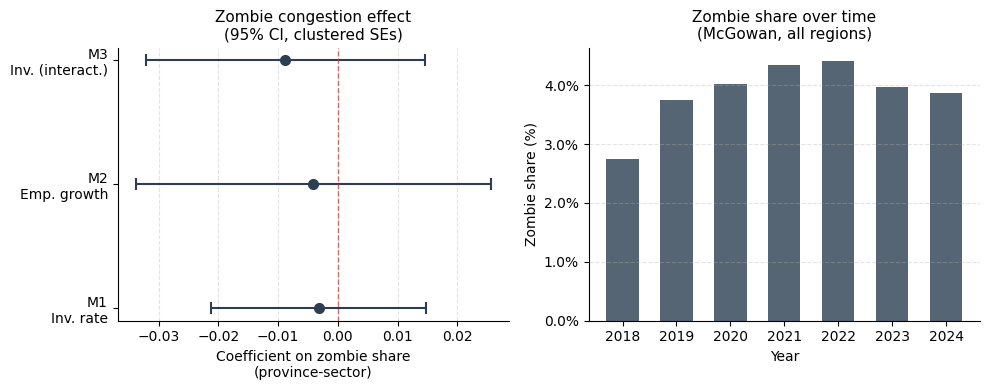

Saved: nb3_coefficient_plot.png


In [54]:
def get_ci(res, engine, var):
    """Get point estimate and 95% CI for a variable."""
    try:
        if engine == 'linearmodels':
            coef = res.params[var]
            se   = res.std_errors[var]
        else:
            coef = res.params[var]
            se   = res.bse[var]
        return coef, coef - 1.96*se, coef + 1.96*se
    except KeyError:
        return None, None, None

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: zombie_share_loo coefficients across models 1-3
ax = axes[0]
model_labels = ['M1\nInv. rate', 'M2\nEmp. growth', 'M3\nInv. (interact.)']
plot_models  = [(res_m1, engine_m1), (res_m2, engine_m2), (res_m3, engine_m3)]
ys = range(len(plot_models))

for y, (res, eng), label in zip(ys, plot_models, model_labels):
    coef, lo, hi = get_ci(res, eng, 'zombie_share_loo')
    if coef is not None:
        ax.errorbar(coef, y, xerr=[[coef-lo], [hi-coef]],
                    fmt='o', color='#2c3e50', capsize=4, capthick=1.5, linewidth=1.5, markersize=7)

ax.axvline(0, color='#c0392b', linestyle='--', linewidth=1, alpha=0.7)
ax.set_yticks(list(ys))
ax.set_yticklabels(model_labels, fontsize=10)
ax.set_xlabel('Coefficient on zombie share\n(province-sector)', fontsize=10)
ax.set_title('Zombie congestion effect\n(95% CI, clustered SEs)', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.spines[['top','right']].set_visible(False)

# Right: zombie share over time (descriptive, for context)
ax = axes[1]
ts = (df[df[PRIMARY_ZOMBIE].notna()]
      .groupby('year')[PRIMARY_ZOMBIE].mean() * 100)
ax.bar(ts.index, ts.values, color='#2c3e50', alpha=0.8, width=0.6)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Zombie share (%)', fontsize=10)
ax.set_title(f'Zombie share over time\n(McGowan, all regions)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb3_coefficient_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb3_coefficient_plot.png")


## 5. Descriptive statistics table

In [55]:
desc_vars = {
    'investment_rate'    : 'Investment rate',
    'emp_growth_w'       : 'Employment growth (log diff)',
    'zombie_share_loo'   : 'Zombie share (province-sector)',
    'icr'                : 'ICR',
    'roa'                : 'ROA',
    'total_assets'       : 'Total assets (€ thousands)',
    'employees'          : 'Employees',
    PRIMARY_ZOMBIE       : 'Zombie — McGowan (0/1)',
    'zombie_storz'       : 'Zombie — Storz (0/1)',
}

rows = []
for col, label in desc_vars.items():
    if col not in df.columns:
        continue
    sub = df.loc[df['year'].isin(REG_YEARS), col].dropna()
    rows.append({
        'Variable'  : label,
        'N'         : f"{len(sub):,}",
        'Mean'      : f"{sub.mean():.4f}",
        'Std. dev.' : f"{sub.std():.4f}",
        'p10'       : f"{sub.quantile(.10):.4f}",
        'Median'    : f"{sub.median():.4f}",
        'p90'       : f"{sub.quantile(.90):.4f}",
    })

desc_df = pd.DataFrame(rows).set_index('Variable')
print("Descriptive statistics (regression sample years):")
print(desc_df.to_string())
desc_df.to_csv(OUTPUT_DIR / 'nb3_descriptive_stats.csv')
print("\nSaved: nb3_descriptive_stats.csv")


Descriptive statistics (regression sample years):
                                      N        Mean    Std. dev.       p10     Median         p90
Variable                                                                                         
Investment rate                 462,035      0.2549      31.4019   -0.0350    -0.0009      0.0941
Employment growth (log diff)    302,248      0.0188       0.1445   -0.1301     0.0000      0.1775
Zombie share (province-sector)  512,841      0.0385       0.0385    0.0000     0.0304      0.0811
ICR                             446,361   1263.6608   51855.9518   -3.5994     5.9087    156.4752
ROA                             473,080      5.7661    4975.4058   -0.0350     0.0235      0.1270
Total assets (€ thousands)      473,088  20789.3718  557445.4098  527.0539  2926.8055  23154.3774
Employees                       380,167     61.9758     452.8567   11.0000    20.0000     87.0000
Zombie — McGowan (0/1)          523,082      0.0387       0.1930    

## 6. Robustness A — Drop `icr_lag_w` (recover ~84k obs)

`icr_lag_w` requires both valid EBIT, positive financial expenses, *and* a prior-year observation, so including it costs roughly 84,000 firm-year observations from the spillover sample. Firms with zero debt (no financial expenses) are entirely excluded, which skews the sample toward more leveraged firms. These models drop `icr_lag_w` to check whether the null spillover result is an artefact of that selection.

In [56]:
indep_m1b = ['zombie_share_loo', 'log_ta']

res_m1b, sub_m1b, engine_m1b = run_panel_ols(
    spill, 'inv_rate_w', indep_m1b,
    label='M1b: Investment ~ zombie congestion (no ICR lag)'
)
print(f"Model 1b — Investment rate, no ICR lag (engine: {engine_m1b})")
print(f"N = {len(sub_m1b):,} obs | firms = {sub_m1b['bvd_id'].nunique():,}")
print(f"N gain vs M1: +{len(sub_m1b) - len(sub_m1):,} obs")
print()
if engine_m1b == 'linearmodels':
    print(res_m1b.summary.tables[1])
else:
    print(res_m1b.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


Model 1b — Investment rate, no ICR lag (engine: linearmodels)
N = 434,292 obs | firms = 72,530
N gain vs M1: +83,072 obs

                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0046     0.0082    -0.5644     0.5725     -0.0207      0.0114
log_ta               0.0308     0.0011     27.878     0.0000      0.0286      0.0329


In [57]:
spill_emp2 = spill[spill['emp_growth_w'].notna()].copy()
indep_m2b = ['zombie_share_loo', 'log_ta']

res_m2b, sub_m2b, engine_m2b = run_panel_ols(
    spill_emp2, 'emp_growth_w', indep_m2b,
    label='M2b: Employment growth ~ zombie congestion (no ICR lag)'
)
print(f"Model 2b — Employment growth, no ICR lag (engine: {engine_m2b})")
print(f"N = {len(sub_m2b):,} obs | firms = {sub_m2b['bvd_id'].nunique():,}")
print(f"N gain vs M2: +{len(sub_m2b) - len(sub_m2):,} obs")
print()
if engine_m2b == 'linearmodels':
    print(res_m2b.summary.tables[1])
else:
    print(res_m2b.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


Model 2b — Employment growth, no ICR lag (engine: linearmodels)
N = 285,289 obs | firms = 62,130
N gain vs M2: +0 obs

                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0041     0.0152    -0.2694     0.7876     -0.0339      0.0257
log_ta               0.0567     0.0022     26.156     0.0000      0.0525      0.0610


In [58]:
spill_hc2 = spill[spill['high_credit'].notna()].copy()
spill_hc2['zombie_x_hc'] = spill_hc2['zombie_share_loo'] * spill_hc2['high_credit']
indep_m3b = ['zombie_share_loo', 'zombie_x_hc', 'high_credit', 'log_ta']

res_m3b, sub_m3b, engine_m3b = run_panel_ols(
    spill_hc2, 'inv_rate_w', indep_m3b,
    label='M3b: Investment x credit intensity (no ICR lag)'
)
print(f"Model 3b — Investment x credit, no ICR lag (engine: {engine_m3b})")
print(f"N = {len(sub_m3b):,} obs")
print()
if engine_m3b == 'linearmodels':
    print(res_m3b.summary.tables[1])
else:
    print(res_m3b.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


Model 3b — Investment x credit, no ICR lag (engine: linearmodels)
N = 434,292 obs

                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0066     0.0108    -0.6153     0.5384     -0.0277      0.0145
zombie_x_hc          0.0054     0.0124     0.4405     0.6595     -0.0188      0.0297
high_credit         -0.0114     0.0008    -14.356     0.0000     -0.0129     -0.0098
log_ta               0.0310     0.0011     28.163     0.0000      0.0289      0.0332


In [59]:
indep_m4b = [PRIMARY_ZOMBIE, 'log_ta']

res_m4b, sub_m4b, engine_m4b = run_panel_ols(
    full, 'inv_rate_w', indep_m4b,
    label='M4b: Investment ~ own zombie (no ICR lag)'
)
print(f"Model 4b — Own zombie, no ICR lag (engine: {engine_m4b})")
print(f"N = {len(sub_m4b):,} obs | firms = {sub_m4b['bvd_id'].nunique():,}")
print(f"N gain vs M4: +{len(sub_m4b) - len(sub_m4):,} obs")
print()
if engine_m4b == 'linearmodels':
    print(res_m4b.summary.tables[1])
else:
    print(res_m4b.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


Model 4b — Own zombie, no ICR lag (engine: linearmodels)
N = 462,035 obs | firms = 74,700
N gain vs M4: +86,758 obs

                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
zombie_mcgowan    -0.0041     0.0009    -4.3681     0.0000     -0.0059     -0.0022
log_ta             0.0279     0.0010     28.345     0.0000      0.0260      0.0299


## 7. Robustness B — Northern Italy subsample (ITC + ITH NUTS2)

The spillover literature finds effects concentrated in regions with denser industrial networks and tighter credit markets. Northern Italy (NUTS2 codes ITC: Piemonte, Valle d'Aosta, Liguria, Lombardia; ITH: Trentino-Alto Adige, Veneto, Friuli-Venezia Giulia, Emilia-Romagna) has higher zombie concentration and more integrated inter-firm credit relationships. This subsample tests whether the null national result masks a significant Northern effect.

Both specifications are run: with and without `icr_lag_w`.

In [60]:
# Northern Italy: NUTS2 prefixes ITC (North-West) and ITH (North-East)
north_mask = df['nuts2_code'].str.startswith('ITC') | df['nuts2_code'].str.startswith('ITH')
df_north = df[north_mask].copy()

print(f"Northern Italy subsample: {df_north['bvd_id'].nunique():,} unique firms")
print(f"NUTS2 regions included:")
for code, cnt in df_north[df_north['year']==2022]['nuts2_code'].value_counts().items():
    print(f"  {code}: {cnt:,} firms")

# Rebuild province_sector for North only (same logic)
df_north['province_sector'] = (df_north['province'].astype(str) + '_' +
                                df_north['nace_2digit'].astype(str))

# Spillover and full samples for North
spill_n = df_north[
    (df_north[PRIMARY_ZOMBIE] == 0) &
    df_north['zombie_share_loo'].notna() &
    df_north['inv_rate_w'].notna()
].copy()

full_n = df_north[
    df_north['inv_rate_w'].notna() &
    df_north[PRIMARY_ZOMBIE].notna()
].copy()

print(f"\nNorth spillover sample : {len(spill_n):,} obs | {spill_n['bvd_id'].nunique():,} firms")
print(f"North full sample      : {len(full_n):,} obs | {full_n['bvd_id'].nunique():,} firms")


Northern Italy subsample: 47,734 unique firms
NUTS2 regions included:
  ITC4: 19,026 firms
  ITH3: 10,706 firms
  ITH5: 8,397 firms
  ITC1: 5,797 firms
  ITH4: 1,784 firms
  ITC3: 971 firms
  ITH2: 524 firms
  ITH1: 466 firms
  ITC2: 63 firms

North spillover sample : 283,660 obs | 46,726 firms
North full sample      : 299,775 obs | 47,727 firms


### 7.1 Northern subsample — with `icr_lag_w`

In [61]:
res_m1n, sub_m1n, engine_m1n = run_panel_ols(
    spill_n, 'inv_rate_w', ['zombie_share_loo', 'log_ta', 'icr_lag_w'],
    label='M1n: North — Investment ~ zombie congestion'
)
print(f"M1 North — Investment rate (N={len(sub_m1n):,}, firms={sub_m1n['bvd_id'].nunique():,})")
if engine_m1n == 'linearmodels': print(res_m1n.summary.tables[1])
else: print(res_m1n.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


M1 North — Investment rate (N=228,696, firms=45,462)
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo -1.314e-05     0.0119    -0.0011     0.9991     -0.0233      0.0233
log_ta               0.0493     0.0021     23.297     0.0000      0.0452      0.0535
icr_lag_w         1.569e-06  2.199e-07     7.1334     0.0000   1.138e-06       2e-06


In [62]:
spill_emp_n = spill_n[spill_n['emp_growth_w'].notna()].copy()
res_m2n, sub_m2n, engine_m2n = run_panel_ols(
    spill_emp_n, 'emp_growth_w', ['zombie_share_loo', 'log_ta'],
    label='M2n: North — Employment growth ~ zombie congestion'
)
print(f"M2 North — Employment growth (N={len(sub_m2n):,})")
if engine_m2n == 'linearmodels': print(res_m2n.summary.tables[1])
else: print(res_m2n.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


M2 North — Employment growth (N=194,060)
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0061     0.0179    -0.3412     0.7329     -0.0411      0.0289
log_ta               0.0615     0.0026     23.667     0.0000      0.0564      0.0666


In [63]:
spill_hc_n = spill_n[spill_n['high_credit'].notna()].copy()
spill_hc_n['zombie_x_hc'] = spill_hc_n['zombie_share_loo'] * spill_hc_n['high_credit']
res_m3n, sub_m3n, engine_m3n = run_panel_ols(
    spill_hc_n, 'inv_rate_w',
    ['zombie_share_loo', 'zombie_x_hc', 'high_credit', 'log_ta', 'icr_lag_w'],
    label='M3n: North — Investment x credit'
)
print(f"M3 North — Investment x credit (N={len(sub_m3n):,})")
if engine_m3n == 'linearmodels': print(res_m3n.summary.tables[1])
else: print(res_m3n.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


M3 North — Investment x credit (N=228,696)
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0111     0.0146    -0.7616     0.4463     -0.0397      0.0175
zombie_x_hc          0.0238     0.0158     1.5081     0.1315     -0.0071      0.0548
high_credit         -0.0086     0.0010    -8.5573     0.0000     -0.0106     -0.0066
log_ta               0.0493     0.0021     23.306     0.0000      0.0452      0.0535
icr_lag_w         1.526e-06  2.193e-07     6.9611     0.0000   1.097e-06   1.956e-06


In [64]:
res_m4n, sub_m4n, engine_m4n = run_panel_ols(
    full_n, 'inv_rate_w', [PRIMARY_ZOMBIE, 'log_ta', 'icr_lag_w'],
    label='M4n: North — Own zombie'
)
print(f"M4 North — Own zombie (N={len(sub_m4n):,}, firms={sub_m4n['bvd_id'].nunique():,})")
if engine_m4n == 'linearmodels': print(res_m4n.summary.tables[1])
else: print(res_m4n.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


M4 North — Own zombie (N=242,843, firms=46,569)
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
zombie_mcgowan    -0.0033     0.0013    -2.4961     0.0126     -0.0060     -0.0007
log_ta             0.0430     0.0018     23.324     0.0000      0.0394      0.0466
icr_lag_w       1.584e-06  2.167e-07     7.3096     0.0000   1.159e-06   2.009e-06


### 7.2 Northern subsample — without `icr_lag_w`

In [65]:
res_m1nb, sub_m1nb, engine_m1nb = run_panel_ols(
    spill_n, 'inv_rate_w', ['zombie_share_loo', 'log_ta'],
    label='M1nb: North — Investment, no ICR lag'
)
print(f"M1 North (no ICR) — Investment rate (N={len(sub_m1nb):,}, firms={sub_m1nb['bvd_id'].nunique():,})")
print(f"N gain vs M1n: +{len(sub_m1nb)-len(sub_m1n):,} obs")
if engine_m1nb == 'linearmodels': print(res_m1nb.summary.tables[1])
else: print(res_m1nb.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


M1 North (no ICR) — Investment rate (N=283,660, firms=46,726)
N gain vs M1n: +54,964 obs
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0045     0.0103    -0.4377     0.6616     -0.0247      0.0157
log_ta               0.0356     0.0015     24.503     0.0000      0.0327      0.0384


In [66]:
spill_emp_nb = spill_n[spill_n['emp_growth_w'].notna()].copy()
res_m2nb, sub_m2nb, engine_m2nb = run_panel_ols(
    spill_emp_nb, 'emp_growth_w', ['zombie_share_loo', 'log_ta'],
    label='M2nb: North — Employment growth, no ICR lag'
)
print(f"M2 North (no ICR) — Employment growth (N={len(sub_m2nb):,})")
if engine_m2nb == 'linearmodels': print(res_m2nb.summary.tables[1])
else: print(res_m2nb.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


M2 North (no ICR) — Employment growth (N=194,060)
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0061     0.0179    -0.3412     0.7329     -0.0411      0.0289
log_ta               0.0615     0.0026     23.667     0.0000      0.0564      0.0666


In [67]:
spill_hc_nb = spill_n[spill_n['high_credit'].notna()].copy()
spill_hc_nb['zombie_x_hc'] = spill_hc_nb['zombie_share_loo'] * spill_hc_nb['high_credit']
res_m3nb, sub_m3nb, engine_m3nb = run_panel_ols(
    spill_hc_nb, 'inv_rate_w',
    ['zombie_share_loo', 'zombie_x_hc', 'high_credit', 'log_ta'],
    label='M3nb: North — Investment x credit, no ICR lag'
)
print(f"M3 North (no ICR) — Investment x credit (N={len(sub_m3nb):,})")
if engine_m3nb == 'linearmodels': print(res_m3nb.summary.tables[1])
else: print(res_m3nb.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


M3 North (no ICR) — Investment x credit (N=283,660)
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0065     0.0128    -0.5056     0.6132     -0.0315      0.0186
zombie_x_hc          0.0077     0.0157     0.4911     0.6233     -0.0231      0.0385
high_credit         -0.0106     0.0010    -10.665     0.0000     -0.0126     -0.0087
log_ta               0.0358     0.0015     24.660     0.0000      0.0330      0.0386


In [68]:
res_m4nb, sub_m4nb, engine_m4nb = run_panel_ols(
    full_n, 'inv_rate_w', [PRIMARY_ZOMBIE, 'log_ta'],
    label='M4nb: North — Own zombie, no ICR lag'
)
print(f"M4 North (no ICR) — Own zombie (N={len(sub_m4nb):,}, firms={sub_m4nb['bvd_id'].nunique():,})")
if engine_m4nb == 'linearmodels': print(res_m4nb.summary.tables[1])
else: print(res_m4nb.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|','[0.025','0.975]']])


M4 North (no ICR) — Own zombie (N=299,775, firms=47,727)
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
zombie_mcgowan    -0.0041     0.0012    -3.5086     0.0005     -0.0063     -0.0018
log_ta             0.0322     0.0013     24.943     0.0000      0.0297      0.0347


## 8. Robustness summary

Collects the zombie congestion coefficient across all eight robustness specifications alongside the baseline, for a quick cross-comparison.

In [69]:
rob_specs = [
    ('M1 Baseline',        res_m1,   engine_m1,   sub_m1,   'inv_rate_w'),
    ('M1b No ICR lag',     res_m1b,  engine_m1b,  sub_m1b,  'inv_rate_w'),
    ('M1n North',          res_m1n,  engine_m1n,  sub_m1n,  'inv_rate_w'),
    ('M1nb North+no ICR',  res_m1nb, engine_m1nb, sub_m1nb, 'inv_rate_w'),
    ('M2 Baseline',        res_m2,   engine_m2,   sub_m2,   'emp_growth_w'),
    ('M2b No ICR lag',     res_m2b,  engine_m2b,  sub_m2b,  'emp_growth_w'),
    ('M2n North',          res_m2n,  engine_m2n,  sub_m2n,  'emp_growth_w'),
    ('M2nb North+no ICR',  res_m2nb, engine_m2nb, sub_m2nb, 'emp_growth_w'),
]

rob_rows = []
for label, res, eng, sub, dep in rob_specs:
    coef, lo, hi = get_ci(res, eng, 'zombie_share_loo')
    coefs = extract_coefs(res, eng, ['zombie_share_loo'])
    rob_rows.append({
        'Spec'       : label,
        'Dep. var.'  : dep,
        'Coef'       : coefs.get('zombie_share_loo', '—'),
        'N obs'      : f"{len(sub):,}",
        'N firms'    : f"{sub['bvd_id'].nunique():,}",
        'ICR lag'    : 'No' if 'no ICR' in label.lower() or 'no icr' in label.lower() else 'Yes',
        'North only' : 'Yes' if 'North' in label else 'No',
    })

rob_df = pd.DataFrame(rob_rows).set_index('Spec')
print("\nROBUSTNESS — Zombie congestion coefficient (zombie_share_loo)")
print("="*85)
print(rob_df.to_string())
print("="*85)
print("Coef format: point estimate (*** p<0.01, ** p<0.05, * p<0.10) / (SE)")

rob_df.to_csv(OUTPUT_DIR / 'nb3_robustness_summary.csv')
print("\nSaved: nb3_robustness_summary.csv")



ROBUSTNESS — Zombie congestion coefficient (zombie_share_loo)
                      Dep. var.               Coef    N obs N firms ICR lag North only
Spec                                                                                  
M1 Baseline          inv_rate_w  -0.0032\n(0.0092)  351,220  70,329     Yes         No
M1b No ICR lag       inv_rate_w  -0.0046\n(0.0082)  434,292  72,530      No         No
M1n North            inv_rate_w  -0.0000\n(0.0119)  228,696  45,462     Yes        Yes
M1nb North+no ICR    inv_rate_w  -0.0045\n(0.0103)  283,660  46,726      No        Yes
M2 Baseline        emp_growth_w  -0.0041\n(0.0152)  285,289  62,130     Yes         No
M2b No ICR lag     emp_growth_w  -0.0041\n(0.0152)  285,289  62,130      No         No
M2n North          emp_growth_w  -0.0061\n(0.0179)  194,060  41,026     Yes        Yes
M2nb North+no ICR  emp_growth_w  -0.0061\n(0.0179)  194,060  41,026      No        Yes
Coef format: point estimate (*** p<0.01, ** p<0.05, * p<0.10) / (SE

## 9. Check 2 — Unconsolidated-only robustness

Re-runs M1 and M4 restricting to U1/U2 firms only. Reads `zombie_panel_classified_u.parquet` written by NB1 check 2.

In [70]:
u_file = BASE_DIR / 'zombie_panel_classified_u.parquet'

if not u_file.exists():
    print('File not found — run NB1 check 2 first.')
else:
    df_u = pd.read_parquet(u_file)
    df_u = df_u[df_u['year'].isin(REG_YEARS)].copy()

    # zombie_panel_classified_u was written before NB2 adds province/nuts cols.
    # Derive province from nuts3 column using the same logic as NB2.
    if 'province' not in df_u.columns:
        def _parse_nuts3(s):
            if pd.isna(s) or ' - ' not in str(s): return (np.nan, np.nan, np.nan)
            code, name = str(s).split(' - ', 1)
            return code.strip(), name.strip(), code.strip()[:4]
        parsed = df_u['nuts3'].apply(_parse_nuts3)
        df_u['nuts3_code'] = parsed.apply(lambda x: x[0])
        df_u['province']   = parsed.apply(lambda x: x[1])
        df_u['nuts2_code'] = parsed.apply(lambda x: x[2])
        print(f'Province parsed from nuts3: '
              f'{df_u["province"].notna().mean():.1%} coverage')

    df_u = df_u.sort_values(['bvd_id','year'])
    df_u['icr_w']        = winsorise(df_u['icr'])
    df_u['icr_lag_w']    = df_u.groupby('bvd_id')['icr_w'].shift(1)
    df_u['log_emp']      = np.log(df_u['employees'].clip(lower=1))
    df_u['emp_growth']   = df_u.groupby('bvd_id')['log_emp'].diff()
    df_u['emp_growth_w'] = winsorise(df_u['emp_growth'])
    df_u['inv_rate_w']   = winsorise(df_u['investment_rate'])
    df_u['log_ta']       = np.log(df_u['total_assets'].clip(lower=1))

    cs_u = (
        df_u[df_u[PRIMARY_ZOMBIE].notna()]
        .groupby(['province','nace_2digit','year'])
        .agg(cell_n_zombies=(PRIMARY_ZOMBIE,'sum'), cell_n_firms=(PRIMARY_ZOMBIE,'count'))
        .reset_index()
    )
    cs_u['cell_zombie_share'] = cs_u['cell_n_zombies'] / cs_u['cell_n_firms']
    df_u = df_u.merge(cs_u, on=['province','nace_2digit','year'], how='left')
    mask_u = (df_u[PRIMARY_ZOMBIE].notna()) & (df_u['cell_n_firms'] > 1)
    df_u['zombie_share_loo'] = np.where(
        mask_u,
        (df_u['cell_n_zombies'] - df_u[PRIMARY_ZOMBIE]) / (df_u['cell_n_firms'] - 1),
        df_u['cell_zombie_share']
    )
    df_u.loc[df_u['cell_n_firms'] < MIN_OBS_CELL, 'zombie_share_loo'] = np.nan
    df_u['province_sector'] = df_u['province'].astype(str) + '_' + df_u['nace_2digit'].astype(str)

    spill_u = df_u[(df_u[PRIMARY_ZOMBIE]==0) & df_u['zombie_share_loo'].notna() & df_u['inv_rate_w'].notna()].copy()
    full_u  = df_u[df_u['inv_rate_w'].notna() & df_u[PRIMARY_ZOMBIE].notna()].copy()
    print(f'Unconsolidated-only: {df_u["bvd_id"].nunique():,} firms')
    print(f'  Spillover: {len(spill_u):,} obs | Full: {len(full_u):,} obs')

    res_m1u, sub_m1u, eng_m1u = run_panel_ols(
        spill_u, 'inv_rate_w', ['zombie_share_loo','log_ta','icr_lag_w'], label='M1u')
    res_m4u, sub_m4u, eng_m4u = run_panel_ols(
        full_u,  'inv_rate_w', [PRIMARY_ZOMBIE,'log_ta','icr_lag_w'],    label='M4u')

    print(f'\nM1 Unconsolidated (N={len(sub_m1u):,}):')
    if eng_m1u == 'linearmodels': print(res_m1u.summary.tables[1])
    else: print(res_m1u.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|']])

    print(f'\nM4 Unconsolidated (N={len(sub_m4u):,}):')
    if eng_m4u == 'linearmodels': print(res_m4u.summary.tables[1])
    else: print(res_m4u.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|']])

    print('\nComparison — zombie_share_loo:')
    for lbl, res, eng in [('Baseline M1', res_m1, engine_m1),('Unconsolidated M1', res_m1u, eng_m1u)]:
        c = extract_coefs(res, eng, ['zombie_share_loo'])
        print(f'  {lbl:<25s}: {c["zombie_share_loo"]}')
    print('\nComparison — own zombie:')
    for lbl, res, eng in [('Baseline M4', res_m4, engine_m4),('Unconsolidated M4', res_m4u, eng_m4u)]:
        c = extract_coefs(res, eng, [PRIMARY_ZOMBIE])
        print(f'  {lbl:<25s}: {c[PRIMARY_ZOMBIE]}')


Province parsed from nuts3: 100.0% coverage
Unconsolidated-only: 73,334 firms
  Spillover: 427,241 obs | Full: 454,545 obs

M1 Unconsolidated (N=345,593):
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0025     0.0092    -0.2719     0.7857     -0.0206      0.0156
log_ta               0.0453     0.0015     29.944     0.0000      0.0424      0.0483
icr_lag_w         1.786e-06  2.076e-07     8.6042     0.0000   1.379e-06   2.193e-06

M4 Unconsolidated (N=369,257):
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
zombie_mcgowan    -0.0027     0.0011    -2.5004     0.

## 10. Check 4 — Capital-weighted congestion robustness

Re-runs M1 using `cap_zombie_share_loo` (share of province-sector tangible assets held by zombies) instead of firm-count share, following McGowan et al. (2018).

In [71]:
spill_cap = df[
    (df[PRIMARY_ZOMBIE] == 0) &
    df['cap_zombie_share_loo'].notna() &
    df['inv_rate_w'].notna()
].copy()

res_m1cap, sub_m1cap, eng_m1cap = run_panel_ols(
    spill_cap, 'inv_rate_w',
    ['cap_zombie_share_loo', 'log_ta', 'icr_lag_w'],
    label='M1cap: Investment ~ capital-weighted zombie congestion'
)
print(f'M1 Capital-weighted congestion (N={len(sub_m1cap):,}, '
      f'firms={sub_m1cap["bvd_id"].nunique():,}):')
if eng_m1cap == 'linearmodels': print(res_m1cap.summary.tables[1])
else: print(res_m1cap.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|']])

print('\nComparison — congestion coefficient:')
for lbl, res, eng, var in [
    ('M1 Count share (baseline)', res_m1,    engine_m1,  'zombie_share_loo'),
    ('M1 Capital share',          res_m1cap, eng_m1cap,  'cap_zombie_share_loo'),
]:
    c = extract_coefs(res, eng, [var])
    print(f'  {lbl:<30s}: {c[var]}')


M1 Capital-weighted congestion (N=356,927, firms=71,491):
                                  Parameter Estimates                                   
                      Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------
cap_zombie_share_loo    -0.0054     0.0030    -1.7714     0.0765     -0.0114      0.0006
log_ta                   0.0454     0.0015     30.458     0.0000      0.0425      0.0483
icr_lag_w             1.814e-06  2.089e-07     8.6844     0.0000   1.405e-06   2.224e-06

Comparison — congestion coefficient:
  M1 Count share (baseline)     : -0.0032
(0.0092)
  M1 Capital share              : -0.0054*
(0.0030)


## 11. Credit channel tests — evergreening mechanism

Three sequential tests of whether zombie congestion operates through credit misallocation:

- **Test 1:** does zombie congestion raise the cost of debt (`fin_intensity`) for healthy firms?
- **Test 2:** does zombie congestion reduce loan growth (`d_log_loans`) for healthy firms?
- **Test 3:** does controlling for credit cost attenuate the investment effect (mediation)?

All models: firm FE + year FE, SEs clustered at province × sector.

In [72]:
# Credit channel variables — built on df then propagated to spill/spill_n
df = df.sort_values(['bvd_id', 'year'])

# Winsorised financial intensity (cost of debt proxy)
df['fin_intensity_w'] = winsorise(df['fin_intensity'])

# Log loan growth
df['log_loans']     = np.log(df['loans_std'].clip(lower=1))
df['d_log_loans']   = df.groupby('bvd_id')['log_loans'].diff()
df['d_log_loans_w'] = winsorise(df['d_log_loans'])

# Propagate new columns to spill and spill_n (they are copies, need refresh)
new_cols = ['fin_intensity_w', 'd_log_loans_w']
for col in new_cols:
    spill[col]   = df.loc[spill.index,   col]
    spill_n[col] = df.loc[spill_n.index, col]
    full[col]    = df.loc[full.index,    col]

print('Credit channel variables constructed:')
for v in new_cols:
    sub = df[df['year'].isin(REG_YEARS)][v].dropna()
    print(f'  {v}: n={len(sub):,}  mean={sub.mean():.4f}  sd={sub.std():.4f}')


Credit channel variables constructed:
  fin_intensity_w: n=473,080  mean=0.0085  sd=0.0098
  d_log_loans_w: n=397,573  mean=0.0402  sd=1.5971


### Test 1 — Zombie congestion and cost of debt

Dependent variable: `fin_intensity_w` (financial expenses / total assets). A positive coefficient on `zombie_share_loo` means healthy firms in zombie-congested province-sectors pay more for debt — consistent with evergreening crowding out credit at the intensive margin (higher rates, not lower volumes).

In [73]:
spill_fi = spill[spill['fin_intensity_w'].notna()].copy()

res_t1, sub_t1, eng_t1 = run_panel_ols(
    spill_fi, 'fin_intensity_w',
    ['zombie_share_loo', 'log_ta'],
    label='T1: Credit cost ~ zombie congestion'
)
print(f'Test 1 — Credit cost (N={len(sub_t1):,}, firms={sub_t1["bvd_id"].nunique():,})')
if eng_t1 == 'linearmodels': print(res_t1.summary.tables[1])
else: print(res_t1.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|']])

# Capital-weighted version
spill_fi_cap = spill_fi[spill_fi['cap_zombie_share_loo'].notna()].copy()
res_t1cap, sub_t1cap, eng_t1cap = run_panel_ols(
    spill_fi_cap, 'fin_intensity_w',
    ['cap_zombie_share_loo', 'log_ta'],
    label='T1cap: Credit cost ~ capital-weighted congestion'
)
print(f'\nTest 1 Capital-weighted (N={len(sub_t1cap):,})')
if eng_t1cap == 'linearmodels': print(res_t1cap.summary.tables[1])
else: print(res_t1cap.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|']])


Test 1 — Credit cost (N=434,292, firms=72,530)
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo     0.0004     0.0007     0.5349     0.5927     -0.0010      0.0017
log_ta              -0.0007  7.786e-05    -9.5158     0.0000     -0.0009     -0.0006

Test 1 Capital-weighted (N=434,291)
                                  Parameter Estimates                                   
                      Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------
cap_zombie_share_loo     0.0002     0.0002     0.7695     0.4416     -0.0003      0.0006
log_ta                  -0.0007  7.787e-05    -9.5121     0.0000     -0.0009     -0.0006


### Test 2 — Zombie congestion and credit volume

Dependent variable: `d_log_loans_w` (log growth in loans & short-term debt). A negative coefficient means zombie congestion reduces credit supply — the extensive margin of the evergreening channel.

In [74]:
spill_loans = spill[spill['d_log_loans_w'].notna()].copy()

res_t2, sub_t2, eng_t2 = run_panel_ols(
    spill_loans, 'd_log_loans_w',
    ['zombie_share_loo', 'log_ta'],
    label='T2: Loan growth ~ zombie congestion'
)
print(f'Test 2 — Loan growth (N={len(sub_t2):,}, firms={sub_t2["bvd_id"].nunique():,})')
if eng_t2 == 'linearmodels': print(res_t2.summary.tables[1])
else: print(res_t2.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|']])

# North
spill_loans_n = spill_n[spill_n['d_log_loans_w'].notna()].copy()
res_t2n, sub_t2n, eng_t2n = run_panel_ols(
    spill_loans_n, 'd_log_loans_w',
    ['zombie_share_loo', 'log_ta'],
    label='T2n: Loan growth ~ zombie congestion (North)'
)
print(f'\nTest 2 North (N={len(sub_t2n):,})')
if eng_t2n == 'linearmodels': print(res_t2n.summary.tables[1])
else: print(res_t2n.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|']])


Test 2 — Loan growth (N=373,093, firms=70,998)
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0419     0.1329    -0.3150     0.7528     -0.3023      0.2186
log_ta               0.2499     0.0114     21.881     0.0000      0.2275      0.2723

Test 2 North (N=243,550)
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo     0.0106     0.1863     0.0568     0.9547     -0.3545      0.3756
log_ta               0.3003     0.0157     19.159     0.0000      0.2696      0.3311


### Test 3 — Mediation: does credit cost absorb the investment effect?

Adds `fin_intensity_w` as a control to M1 on the same sample. Attenuation of `zombie_share_loo` after adding the credit cost control is evidence that the channel operates through debt pricing. No attenuation = investment effect (if any) operates via product market competition.

In [75]:
spill_med = spill[
    spill['fin_intensity_w'].notna() &
    spill['inv_rate_w'].notna()
].copy()

# M1 on restricted sample
res_m1_r, sub_m1_r, eng_m1_r = run_panel_ols(
    spill_med, 'inv_rate_w',
    ['zombie_share_loo', 'log_ta', 'icr_lag_w'],
    label='M1 restricted'
)

# M1 + credit cost
res_t3, sub_t3, eng_t3 = run_panel_ols(
    spill_med, 'inv_rate_w',
    ['zombie_share_loo', 'fin_intensity_w', 'log_ta', 'icr_lag_w'],
    label='T3: Investment ~ zombie + credit cost'
)

print(f'Test 3 — Mediation (N={len(sub_t3):,})')
print('\nWithout credit cost:')
if eng_m1_r == 'linearmodels': print(res_m1_r.summary.tables[1])
else: print(res_m1_r.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|']])
print('\nWith credit cost (fin_intensity_w):')
if eng_t3 == 'linearmodels': print(res_t3.summary.tables[1])
else: print(res_t3.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|']])

try:
    coef_base = float(res_m1_r.params['zombie_share_loo'] if eng_m1_r=='linearmodels' else res_m1_r.params['zombie_share_loo'])
    coef_med  = float(res_t3.params['zombie_share_loo']   if eng_t3=='linearmodels'   else res_t3.params['zombie_share_loo'])
    if coef_base != 0:
        att = (coef_base - coef_med) / abs(coef_base) * 100
        print(f'\nAttenuation: {att:.1f}%  (base={coef_base:.4f}, mediated={coef_med:.4f})')
except Exception as e:
    print(f'Attenuation calc: {e}')


Test 3 — Mediation (N=351,220)

Without credit cost:
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0032     0.0092    -0.3517     0.7250     -0.0212      0.0148
log_ta               0.0453     0.0015     30.108     0.0000      0.0423      0.0482
icr_lag_w         1.821e-06  2.107e-07     8.6434     0.0000   1.408e-06   2.234e-06

With credit cost (fin_intensity_w):
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
zombie_share_loo    -0.0030     0.0092    -0.3299     0.7415     -0.0210      0.0149
fin_intensity_w     -0.6515     0.0362    -17.981     0.0000

## 12. Geographic spillover — spatial scale

**12A** recomputes zombie congestion at NUTS2 × sector (broader) to test whether spillovers reach beyond the province.

**12B** uses geocoordinates from `firm_geocoded.csv` to compute inverse-distance-weighted zombie shares at 25km, 50km, and 100km radii, testing whether physical proximity to zombies matters beyond administrative unit membership.

### 12A — NUTS2-level congestion term

In [76]:
cell_nuts2 = (
    df[df[PRIMARY_ZOMBIE].notna()]
    .groupby(['nuts2_code', 'nace_2digit', 'year'])
    .agg(
        nuts2_n_zombies=(PRIMARY_ZOMBIE, 'sum'),
        nuts2_n_firms  =(PRIMARY_ZOMBIE, 'count'),
    )
    .reset_index()
)
cell_nuts2['nuts2_zombie_share'] = cell_nuts2['nuts2_n_zombies'] / cell_nuts2['nuts2_n_firms']

df = df.merge(cell_nuts2, on=['nuts2_code', 'nace_2digit', 'year'], how='left')

mask2 = (df[PRIMARY_ZOMBIE].notna()) & (df['nuts2_n_firms'] > 1)
df['zombie_share_nuts2_loo'] = np.where(
    mask2,
    (df['nuts2_n_zombies'] - df[PRIMARY_ZOMBIE]) / (df['nuts2_n_firms'] - 1),
    df['nuts2_zombie_share']
)
df.loc[df['nuts2_n_firms'] < MIN_OBS_CELL, 'zombie_share_nuts2_loo'] = np.nan
df['nuts2_sector'] = df['nuts2_code'].astype(str) + '_' + df['nace_2digit'].astype(str)

corr_n2 = df[['zombie_share_loo','zombie_share_nuts2_loo']].corr().iloc[0,1]
print(f'NUTS2 congestion: {df["zombie_share_nuts2_loo"].notna().sum():,} non-missing')
print(f'Mean: {df["zombie_share_nuts2_loo"].mean():.4f}  Corr with NUTS3: {corr_n2:.3f}')


NUTS2 congestion: 522,102 non-missing
Mean: 0.0387  Corr with NUTS3: 0.648


In [77]:
spill_n2 = df[
    (df[PRIMARY_ZOMBIE] == 0) &
    df['zombie_share_nuts2_loo'].notna() &
    df['inv_rate_w'].notna()
].copy()

res_m1_n2, sub_m1_n2, eng_m1_n2 = run_panel_ols(
    spill_n2, 'inv_rate_w',
    ['zombie_share_nuts2_loo', 'log_ta', 'icr_lag_w'],
    cluster_var='nuts2_sector',
    label='M1-NUTS2'
)
print(f'M1 NUTS2 congestion (N={len(sub_m1_n2):,}, firms={sub_m1_n2["bvd_id"].nunique():,})')
if eng_m1_n2 == 'linearmodels': print(res_m1_n2.summary.tables[1])
else: print(res_m1_n2.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|']])

spill_emp_n2 = spill_n2[spill_n2['emp_growth_w'].notna()].copy()
res_m2_n2, sub_m2_n2, eng_m2_n2 = run_panel_ols(
    spill_emp_n2, 'emp_growth_w',
    ['zombie_share_nuts2_loo', 'log_ta'],
    cluster_var='nuts2_sector',
    label='M2-NUTS2'
)
print(f'\nM2 NUTS2 congestion (N={len(sub_m2_n2):,})')
if eng_m2_n2 == 'linearmodels': print(res_m2_n2.summary.tables[1])
else: print(res_m2_n2.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|']])

print('\nGeographic scale comparison — investment:')
for lbl, res, eng, var in [
    ('NUTS3 province',    res_m1,    engine_m1,  'zombie_share_loo'),
    ('NUTS2 region',      res_m1_n2, eng_m1_n2,  'zombie_share_nuts2_loo'),
    ('Capital-weighted',  res_m1cap, eng_m1cap,  'cap_zombie_share_loo'),
]:
    c = extract_coefs(res, eng, [var])
    print(f'  {lbl:<22s}: {list(c.values())[0]}')


M1 NUTS2 congestion (N=357,558, firms=71,593)
                                   Parameter Estimates                                    
                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------
zombie_share_nuts2_loo     0.0045     0.0217     0.2075     0.8356     -0.0380      0.0470
log_ta                     0.0453     0.0021     21.146     0.0000      0.0411      0.0495
icr_lag_w               1.815e-06  2.338e-07     7.7653     0.0000   1.357e-06   2.274e-06

M2 NUTS2 congestion (N=290,131)
                                   Parameter Estimates                                    
                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------
zombie_share_nuts2_loo    -0.0328     0.0284    -1.1575     0.2470     -0.0884      0.0228
log_ta     

### 12B — Distance-weighted spatial zombie share

Inverse-distance-weighted zombie share within 25km, 50km, and 100km radii. Uses `firm_geocoded.csv` from NB2. Computationally intensive — ~3–5 min.

In [78]:
import os
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

GEO_FILE      = BASE_DIR / "geo" / "firm_geocoded.csv"
SPATIAL_CACHE = BASE_DIR / "spatial_zombie_shares.parquet"
LAT_KM, LON_KM = 111.0, 78.5
BANDWIDTHS     = [25, 50, 100]
# Reduced batch size to stay within ~500MB peak memory per batch
# 500 x 70000 x 8 bytes = ~280MB — safe on 8GB machines
BATCH_SIZE     = 500

# ── Load geocoordinates ───────────────────────────────────────────────────
if not GEO_FILE.exists():
    print(f"firm_geocoded.csv not found at {GEO_FILE} — run NB2 first.")
    firm_geo = None
else:
    firm_geo = pd.read_csv(GEO_FILE)
    firm_geo = firm_geo[firm_geo["lat"].notna() & firm_geo["lon"].notna()].copy()
    print(f"Geocoded firms: {len(firm_geo):,}")
    df_geo = df.merge(firm_geo[["bvd_id","lat","lon"]], on="bvd_id", how="left")
    print(f"Panel rows with coords: {df_geo['lat'].notna().mean():.1%}")

# ── Compute or load spatial zombie shares ─────────────────────────────────
if firm_geo is not None:
    if SPATIAL_CACHE.exists():
        spatial_df = pd.read_parquet(SPATIAL_CACHE)
        print(f"Loaded from cache: {len(spatial_df):,} rows")
    else:
        df_geo["y_km"] = df_geo["lat"] * LAT_KM
        df_geo["x_km"] = df_geo["lon"] * LON_KM
        all_rows = []
        import time as _time
        t0 = _time.time()
        print("Computing distance-weighted zombie shares...")
        print(f"  BATCH_SIZE={BATCH_SIZE} (~{BATCH_SIZE*70000*8/1e6:.0f}MB peak per batch)")

        for yr in sorted(r for r in df_geo["year"].dropna().unique() if r in REG_YEARS):
            yr_df = df_geo[
                (df_geo["year"] == yr) &
                df_geo[PRIMARY_ZOMBIE].notna() &
                df_geo["x_km"].notna()
            ].reset_index(drop=True)
            if len(yr_df) < 10: continue

            coords  = yr_df[["x_km","y_km"]].values.astype(np.float32)  # float32 halves memory
            zombie  = yr_df[PRIMARY_ZOMBIE].values.astype(np.float32)
            bvd_ids = yr_df["bvd_id"].values
            N       = len(yr_df)
            result  = {bw: np.full(N, np.nan, dtype=np.float32) for bw in BANDWIDTHS}

            for start in range(0, N, BATCH_SIZE):
                end   = min(start + BATCH_SIZE, N)
                batch = coords[start:end]                          # (B, 2)
                # (B, N) distance matrix — float32 halves vs float64
                diff  = batch[:, np.newaxis, :] - coords[np.newaxis, :, :]  # (B, N, 2)
                dists = np.sqrt((diff**2).sum(axis=2))             # (B, N)
                # Mask self
                dists[np.arange(end - start), np.arange(start, end)] = np.inf
                # Floor co-located
                dists = np.where(dists < 0.1, 0.1, dists)

                for bw in BANDWIDTHS:
                    mask     = dists <= bw
                    weights  = np.where(mask, 1.0 / dists, 0.0)
                    w_sum    = weights.sum(axis=1)
                    w_zombie = (weights * zombie[np.newaxis, :]).sum(axis=1)
                    result[bw][start:end] = np.where(w_sum > 0, w_zombie / w_sum, np.nan)

                del diff, dists  # free immediately after each batch

            for i_firm in range(N):
                row = {"bvd_id": bvd_ids[i_firm], "year": yr}
                for bw in BANDWIDTHS:
                    row[f"spatial_zombie_{bw}km"] = float(result[bw][i_firm])
                all_rows.append(row)
            print(f"  {int(yr)}: {N:,} firms  ({_time.time()-t0:.0f}s elapsed)")

        spatial_df = pd.DataFrame(all_rows)
        spatial_df.to_parquet(SPATIAL_CACHE, index=False)
        print(f"Saved cache: {SPATIAL_CACHE}  ({_time.time()-t0:.0f}s total)")

    df = df.merge(spatial_df, on=["bvd_id","year"], how="left")
    print("\nSpatial zombie share columns:")
    for bw in BANDWIDTHS:
        col = f"spatial_zombie_{bw}km"
        if col in df.columns:
            print(f"  {col}: {df[col].notna().sum():,} non-missing  "
                  f"mean={df[col].mean():.4f}")


Geocoded firms: 74,636
Panel rows with coords: 99.9%
Loaded from cache: 522,452 rows

Spatial zombie share columns:
  spatial_zombie_25km: 522,438 non-missing  mean=0.0388
  spatial_zombie_50km: 522,452 non-missing  mean=0.0388
  spatial_zombie_100km: 522,452 non-missing  mean=0.0387


Distance-decay regressions:

  25km (N=357,749):
                                  Parameter Estimates                                  
                     Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------------
spatial_zombie_25km    -0.0161     0.0094    -1.7107     0.0871     -0.0344      0.0023
log_ta                  0.0454     0.0015     30.532     0.0000      0.0425      0.0483
icr_lag_w            1.814e-06  2.092e-07     8.6737     0.0000   1.404e-06   2.224e-06

  50km (N=357,759):
                                  Parameter Estimates                                  
                     Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------------
spatial_zombie_50km    -0.0200     0.0114    -1.7590     0.0786     -0.0423      0.0023
log_ta                  0.0454     0.0015     30.5

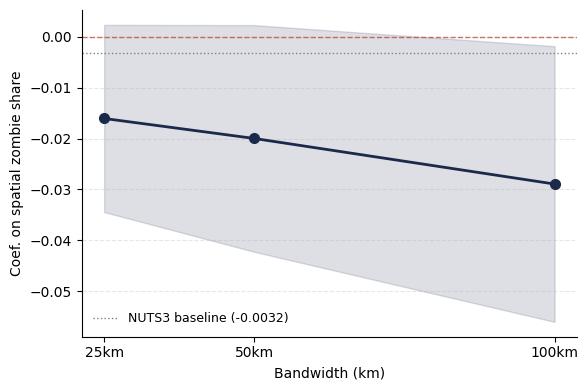

Saved: /Users/leoss/Desktop/Thesis Replication/output/figures/fig_spatial_decay.png


In [79]:
if firm_geo is not None and 'spatial_zombie_50km' in df.columns:
    NAVY, RED = '#1B2A4A', '#C0392B'
    spatial_results = []

    print('Distance-decay regressions:\n')
    for bw in [25, 50, 100]:
        col = f'spatial_zombie_{bw}km'
        if col not in df.columns: continue
        spill_sp = df[
            (df[PRIMARY_ZOMBIE] == 0) &
            df[col].notna() &
            df['inv_rate_w'].notna()
        ].copy()
        if len(spill_sp) < 1000:
            print(f'  {bw}km: too few obs ({len(spill_sp):,}), skipping')
            continue
        res_sp, sub_sp, eng_sp = run_panel_ols(
            spill_sp, 'inv_rate_w', [col, 'log_ta', 'icr_lag_w'],
            label=f'Spatial {bw}km'
        )
        coef, lo, hi = get_ci(res_sp, eng_sp, col)
        try:
            pv = float(res_sp.pvalues[col])
        except: pv = 1.0
        stars = '***' if pv<0.01 else ('**' if pv<0.05 else ('*' if pv<0.10 else ''))
        print(f'  {bw}km (N={len(sub_sp):,}):')
        if eng_sp == 'linearmodels': print(res_sp.summary.tables[1])
        else: print(res_sp.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|']])
        print()
        spatial_results.append({'bw': bw, 'coef': coef, 'lo': lo, 'hi': hi, 'stars': stars})

    # Distance-decay plot
    if spatial_results:
        fig, ax = plt.subplots(figsize=(6, 4))
        bws   = [r['bw']   for r in spatial_results]
        coefs = [r['coef'] for r in spatial_results]
        los   = [r['lo'] or 0 for r in spatial_results]
        his   = [r['hi'] or 0 for r in spatial_results]
        ax.fill_between(bws, los, his, alpha=0.15, color=NAVY)
        ax.plot(bws, coefs, color=NAVY, lw=2, marker='o', markersize=7)
        ax.axhline(0, color=RED, lw=1, ls='--', alpha=0.7)
        try:
            nuts3_coef = float(res_m1.params['zombie_share_loo'])
            ax.axhline(nuts3_coef, color='grey', lw=1, ls=':',
                       label=f'NUTS3 baseline ({nuts3_coef:.4f})')
        except: pass
        ax.set_xlabel('Bandwidth (km)', fontsize=10)
        ax.set_ylabel('Coef. on spatial zombie share', fontsize=10)
        ax.set_xticks(bws)
        ax.set_xticklabels([f'{bw}km' for bw in bws])
        ax.legend(frameon=False, fontsize=9)
        ax.spines[['top','right']].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'fig_spatial_decay.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {FIG_DIR}/fig_spatial_decay.png')
else:
    print('Spatial columns not available — run geocoding cell above first.')
